In [2]:
import pandas as pd

In [3]:
df = pd.read_excel("C:/Users/Admin/Desktop/Sharvari/Internship/Thiranex/Task 3/sample_-_superstore.xlsx")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Basic Cleaning Steps

In [4]:
# 1. Remove duplicates
df = df.drop_duplicates()

# 2. Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# 3. Handle missing values
df.isnull().sum()
df = df.fillna({
    'Postal Code': 0,
    'State': 'Unknown'
})

# 4. Fix text formatting
df['Customer Name'] = df['Customer Name'].str.title()
df['City'] = df['City'].str.title()
df['Region'] = df['Region'].str.upper()

# Feature Engineering

In [5]:
# Delivery time
df['Delivery_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Revenue
df['Revenue'] = df['Sales'] * df['Quantity']

# Profit Margin
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

# Month & Year
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

# Automated Reporting

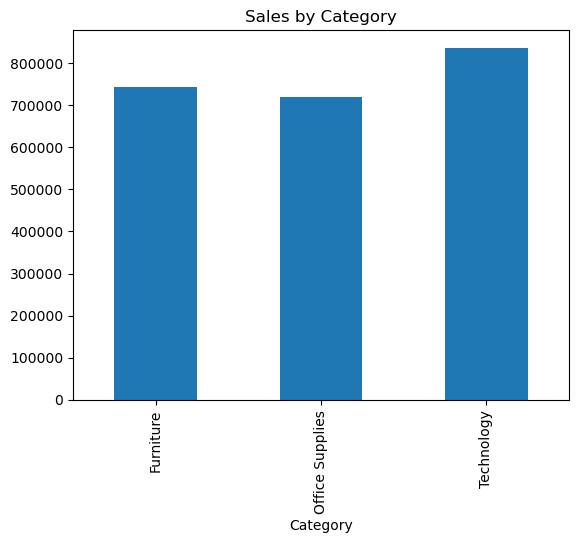

In [15]:
# Sales by Category
import matplotlib.pyplot as plt

df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.savefig("C:/Users/Admin/Desktop/Sharvari/Internship/Thiranex/Task 4/sales_by_category.png")
plt.show()
plt.close()

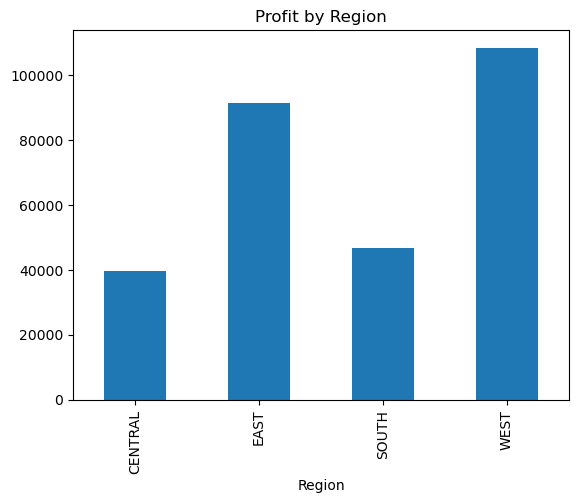

In [16]:
# Profit by Region
df.groupby('Region')['Profit'].sum().plot(kind='bar')
plt.title("Profit by Region")
plt.savefig("C:/Users/Admin/Desktop/Sharvari/Internship/Thiranex/Task 4/profit_by_region.png")
plt.show()
plt.close()

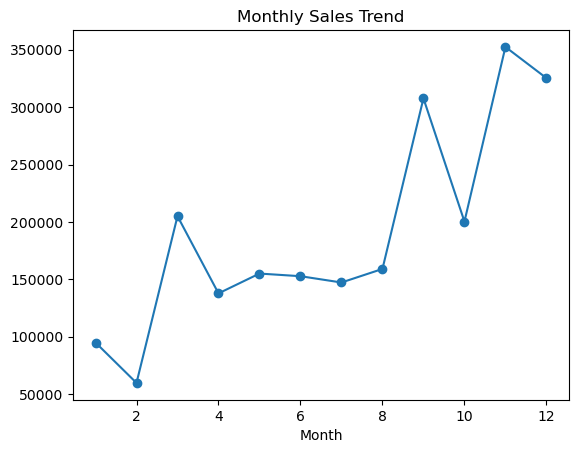

In [17]:
# Monthly Sales Trend
df.groupby('Month')['Sales'].sum().plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.savefig("C:/Users/Admin/Desktop/Sharvari/Internship/Thiranex/Task 4/monthly_sales.png")
plt.show()
plt.close()

In [18]:
# Automation Pipeline
def run_pipeline():
    df = pd.read_excel("C:/Users/Admin/Desktop/Sharvari/Internship/Thiranex/Task 3/sample_-_superstore.xlsx")

    # Cleaning
    df = df.drop_duplicates()
    df['Order Date'] = pd.to_datetime(df['Order Date'])
    df['Ship Date'] = pd.to_datetime(df['Ship Date'])

    # Feature Engineering
    df['Delivery_Days'] = (df['Ship Date'] - df['Order Date']).dt.days
    df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

    # Save cleaned file
    df.to_csv("C:/Users/Admin/Desktop/Sharvari/Internship/Thiranex/Task 4/cleaned_data.csv", index=False)

    # Reports
    generate_reports(df)

def generate_reports(df):
    df.groupby('Category')['Sales'].sum().plot(kind='bar')
    plt.title("Sales by Category")
    plt.savefig("C:/Users/Admin/Desktop/Sharvari/Internship/Thiranex/Task 4/sales_by_category.png")
    plt.close()

if __name__ == "__main__":
    run_pipeline()